In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Canny es el detector de bordes más destacado antes de los modelos de aprendizaje profundo. Un detector más simple es Sobel (realmente suele usarse como primer paso de Canny).
El operador de Sobel considera que cuando hay un borde, el valor de intensidad de los píxeles cercanos cambia de forma notable, calcular las derivadas proporciona una evidencia de dicho cambio. El operador de Sobel aproxima el cálculo de la derivada aplicando un kernel de tamaño impar basado en el patrón [1 2 1].

maxfil = 0.4297
Umbral = 0.3867
Número de filas que cumplen la condición: 7
Filas: [  6  12  15  20  21  88 100]


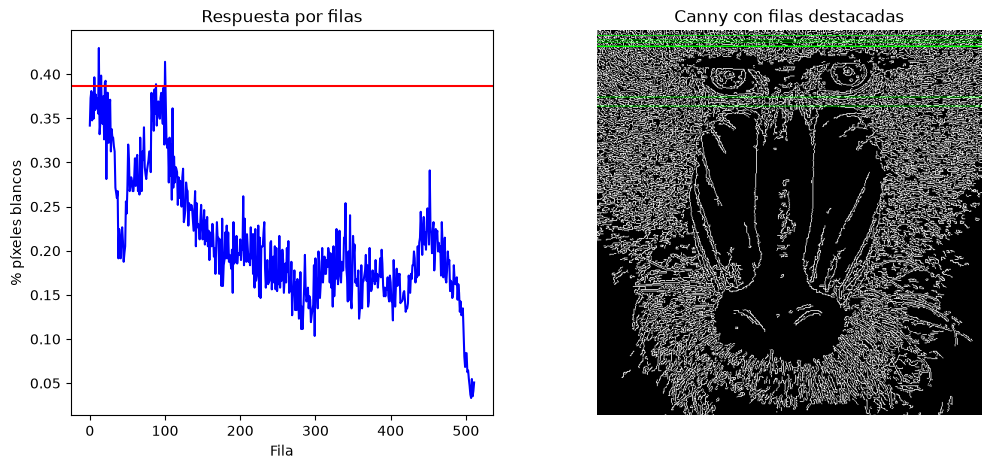

In [ ]:
# El contenido de la imagen resultado de Canny son valores 0 o 255
# Cuenta los píxeles blancos por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Normaliza: % de píxeles blancos por fila
# 255 * ancho = máximo posible de blancos en cada fila
rows = row_counts[:, 0] / (255 * canny.shape[1])

# Valor máximo de píxeles blancos por fila
maxfil = np.max(rows)

# Umbral: 90% del máximo
umbral = 0.90 * maxfil

# Filas que cumplen la condición
filas_ok = np.where(rows >= umbral)[0]

print(f"maxfil = {maxfil:.4f}")
print(f"Umbral = {umbral:.4f}")
print(f"Número de filas que cumplen la condición: {len(filas_ok)}")
print(f"Filas: {filas_ok}")

# Para resaltar en la imagen de Canny, dibujamos una línea horizontal
# en cada fila que cumple la condición
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

for f in filas_ok:
    cv2.line(canny_color, (0, f), (canny.shape[1] - 1, f), (0, 255, 0), 1)

# También podemos mostrar la curva de respuesta por filas y marcar el umbral
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rows, color='blue')
plt.axhline(umbral, color='red') 
plt.title("Respuesta por filas")
plt.xlabel("Fila")
plt.ylabel("% píxeles blancos")

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Canny con filas destacadas")
plt.imshow(canny_color)

plt.show()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [2]:

vid = cv2.VideoCapture(0, cv2.CAP_DSHOW)

while True:
    ret, frame = vid.read()
    if not ret: 
        break

    framem = cv2.flip(frame, 1)

    hsv = cv2.cvtColor(framem, cv2.COLOR_BGR2HSV)

    bajo_piel = np.array([0, 20, 70], dtype=np.uint8)
    alto_piel = np.array([20, 255, 255], dtype=np.uint8)

    mascara = cv2.inRange(hsv, bajo_piel, alto_piel)

    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contorno in contornos:
        area = cv2.contourArea(contorno)
        
        if area > 4000:
            x, y, w, h = cv2.boundingRect(contorno)


            roi = framem[y:y+h, x:x+w]
            
            roi_censurada = cv2.GaussianBlur(roi, (99, 99), 30)
            
            framem[y:y+h, x:x+w] = roi_censurada
            
            cv2.rectangle(framem, (x, y), (x+w, y+h), (200, 200, 200), 2)

    cv2.imshow('Censura por Color de Piel', framem)
    cv2.imshow('Mascara Interna (Depuracion)', mascara)

    # Salir con ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()